# Set-up

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from CIBUSmod.impact.LULUC import LUCTimeSeries

# LUC for MFF scenarios

In [4]:
session = cm.Session(
    name = 'MFF',
    data_path = '../data',
    data_path_output = '../../MFF-scenarios/output'
)

In [65]:
cropland = session.get_attr('C','area',{'crop':'land_use','region':None},interpolate=True).loc[:,'cropland']

In [95]:
%%time
LUC_dfs = []
for scn in cropland.index.unique('scn'):
    CO2E = None
    for re in cropland.columns:
        Ach = cropland.loc[scn,re].diff().fillna(0)
        LUCts = LUCTimeSeries(
            Ach = Ach,
            Cmax = (2_000,50_000),
            T50 = (0.5,20),
            extend = 50
        )
        LUCts.calculate_parcels()
        CO2E = pd.concat([CO2E,LUCts.get_CO2()], axis=1)
    CO2E = CO2E.sum(axis=1)
    LUC_dfs += [pd.concat({scn: CO2E}, names=['scn'])]
LUC = pd.concat(LUC_dfs).rename('CO2').to_frame().rename_axis('compound', axis=1)
LUC.index = LUC.index.set_levels(LUC.index.levels[-1].astype(str), level=-1)

CPU times: total: 3.23 s
Wall time: 3.24 s


In [96]:
ghg = (
    cm.impact.get_GHG(session, CO2eq=None, interpolate=True)
    .rename(lambda x: 'CH4' if 'CH4' in x else ('N2O' if 'N2O' in x else x), axis=1)
    .T.groupby('compound').sum().T
)

In [97]:
dT_LUC = cm.impact.get_deltaT(LUC).rename({'CO2':'LUC'}, axis=1) * 1_000
dT_GHG = cm.impact.get_deltaT(ghg, extend=50) * 1_000

dT = pd.concat([dT_GHG,dT_LUC], axis=1)
dT['TOT'] = dT.sum(axis=1)

Getting GHG emissions ...
Calculating temperature response ...
Getting GHG emissions ...
Calculating temperature response ...


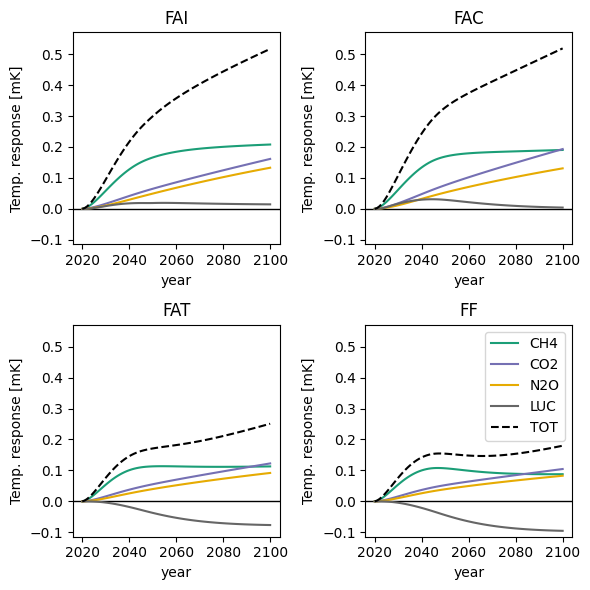

In [98]:
fig,axs = plt.subplots(2,2, figsize=(6,6))
for ax,scn in zip(axs.flatten(),dT.index.unique('scn')):
    ax.axhline(0, color='black', linewidth=1)
    dT.loc[scn].iloc[:,:-1].plot(ax=ax, cmap='Dark2', legend=False)
    dT.loc[scn].iloc[:,[-1]].plot(ax=ax, linestyle='--', color='black', legend=False)
    ax.set_ylim(dT.min().min()*1.2, dT.max().max()*1.1)
    ax.set_title(scn)
    ax.set_ylabel('Temp. response [mK]')
    if ax == axs.flatten()[-1]:
        ax.legend()

plt.tight_layout()
plt.show()

# LUC for constructed time-series

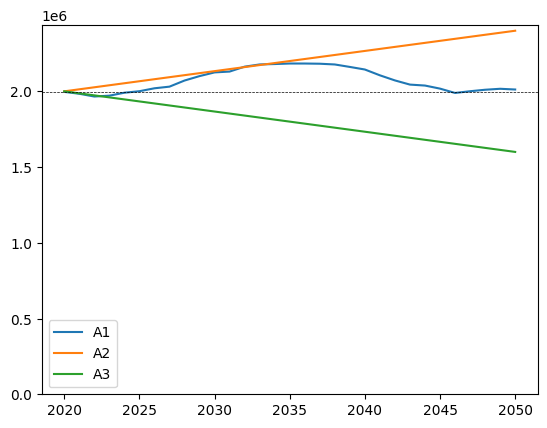

In [4]:
import matplotlib.pyplot as plt

# Generate land use time series
A = {}
A0 = 2_000_000
At = A0
for t in range(2020,2050+1):
    Ach = -np.sin(t/4)*(A0/100) + np.random.randn()*(A0/100/2)
    At += Ach
    A.update({t:At})
    
A1 = pd.Series(A)
A2 = pd.Series({y:At for y,At in zip(range(2020,2050+1),np.linspace(A0,A0*1.2,31))})
A3 = pd.Series({y:At for y,At in zip(range(2020,2050+1),np.linspace(A0,A0*0.8,31))})

ax = A1.plot(label='A1')
A2.plot(ax=ax, label='A2')
A3.plot(ax=ax, label='A3')
ax.axhline(A1.iloc[0], color='black', linestyle='--',linewidth=0.5)
ax.set_ylim(0)
ax.legend()
plt.show()

In [5]:
Ach = A1.diff().fillna(0)
LUCts = LUCTimeSeries(
    Ach = Ach,
    Cmax = (5_000,50_000),
    T50 = (0.5,20),
    extend = 100
)
LUCts.calculate_parcels()